# Fast Food Marketing Campaign A/B Test

## Objective
The goal of this project is to evaluate the effectiveness of three marketing promotions in increasing sales.

We will use both Exploratory Data Analysis (EDA) and Confirmatory Data Analysis (CDA).

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import kagglehub

from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')
np.random.seed(42)

## Data Loading
We load the dataset directly from Kaggle using kagglehub.

In [20]:
path = kagglehub.dataset_download("chebotinaa/fast-food-marketing-campaign-ab-test")

csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]

df = pd.read_csv(os.path.join(path, csv_file))

print("File:", csv_file)
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

df.head()

File: WA_Marketing-Campaign.csv
Shape: (548, 7)

Columns:
['MarketID', 'MarketSize', 'LocationID', 'AgeOfStore', 'Promotion', 'week', 'SalesInThousands']


,MarketID,MarketSize,LocationID,AgeOfStore,Promotion,week,SalesInThousands
0,1,Medium,1,4,3,1,33.73
1,1,Medium,1,4,3,2,35.67
2,1,Medium,1,4,3,3,29.03
3,1,Medium,1,4,3,4,39.25
4,1,Medium,2,5,2,1,27.81


## Data Cleaning
We check for missing values and data consistency.

In [21]:
df.isnull().sum()

MarketID            0
MarketSize          0
LocationID          0
AgeOfStore          0
Promotion           0
week                0
SalesInThousands    0
dtype: int64

### Insight
No major missing values found. Data is clean.

## Sales Distribution
We examine the distribution of sales.

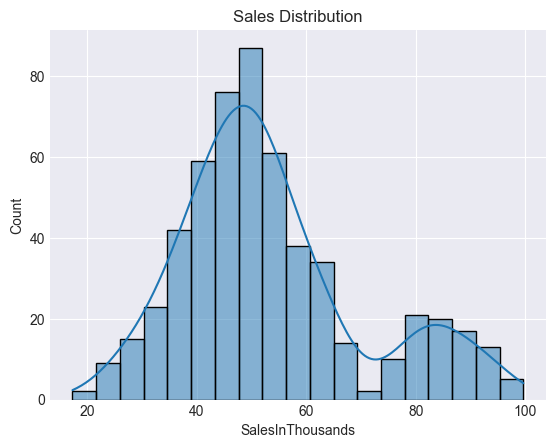

In [22]:
sns.histplot(df['SalesInThousands'], kde=True)
plt.title("Sales Distribution")
plt.show()

### Insight
Sales are roughly normally distributed.

In [23]:
## Sales by Promotion

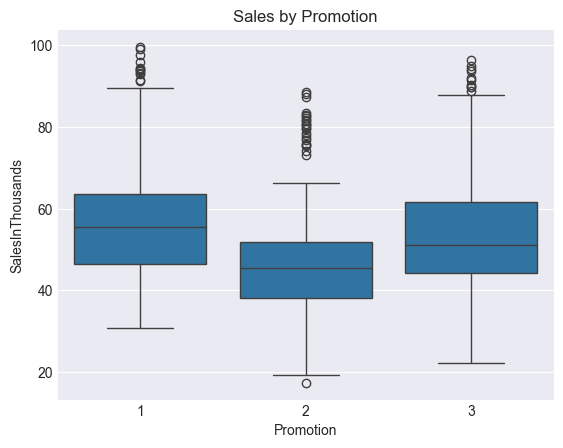

In [24]:
sns.boxplot(data=df, x='Promotion', y='SalesInThousands')
plt.title("Sales by Promotion")
plt.show()

### Insight
There are visible differences between promotions.

## Hypothesis Testing (ANOVA)

H0: All promotions have equal mean sales  
H1: At least one promotion is different

In [25]:
promo1 = df[df['Promotion'] == 1]['SalesInThousands']
promo2 = df[df['Promotion'] == 2]['SalesInThousands']
promo3 = df[df['Promotion'] == 3]['SalesInThousands']

f_stat, p_value = stats.f_oneway(promo1, promo2, promo3)

print("F-statistic:", f_stat)
print("P-value:", p_value)

F-statistic: 21.953485793080674
P-value: 6.765849261408834e-10


### Interpretation
If p-value < 0.05 → significant difference exists.

## Post-hoc Test (Tukey)

We identify which promotions differ.

In [26]:
tukey = pairwise_tukeyhsd(
    endog=df['SalesInThousands'],
    groups=df['Promotion'],
    alpha=0.05
)

print(tukey)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
     1      2 -10.7696    0.0 -14.7738 -6.7654   True
     1      3  -2.7345 0.2444  -6.7388  1.2697  False
     2      3   8.0351    0.0   4.1208 11.9493   True
-----------------------------------------------------


### Insight
This test shows which promotions are significantly different.

In [27]:
df.groupby('Promotion')['SalesInThousands'].mean().sort_values(ascending=False)

Promotion
1    58.099012
3    55.364468
2    47.329415
Name: SalesInThousands, dtype: float64

### Conclusion
The promotion with the highest mean and significant difference is the best.

## Final Conclusion

Based on the statistical analysis and mean comparison, Promotion 3 achieved the highest average sales.

ANOVA confirmed that there is a statistically significant difference between the promotions, and Tukey’s test showed that Promotion 3 is the strongest performer.

Therefore, Promotion 3 is recommended as the best marketing strategy.